In [1]:
#import libarries
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# loading and Understaind the data

In [46]:
data=pd.read_excel('/content/sample_data/Uber Review Data.xlsx')


In [4]:
#watching the  first tow rows table of data
data.head(2)

,Date,Stars,Comment
0,2019-10-29,1,I had an accident with an Uber driver in Mexic...
1,2019-10-28,1,I have had my account completely hacked to whe...


In [5]:
# data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2347 entries, 0 to 2346
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2347 non-null   datetime64[ns]
 1   Stars    2347 non-null   int64         
 2   Comment  2347 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 55.1+ KB


In [6]:
#check missing data
data.isna().sum()
#so no missing data
#no need to drop cels or fill it

,0
Date,0
Stars,0
Comment,0


# Preprocessing the data

In [7]:
#check duplicated  data
data.duplicated().sum()


np.int64(6)

In [47]:
# we have np.int64(415) values or cells that is duplicatedd so wi will drop it
df=data.drop_duplicates(keep='first')

In [9]:
#now we have cleaned data we will devid it fot X data features  which represent input data of the model   and  y Data features which represent the output dat aof the model
x=df['Comment']
y=df['Stars']

In [10]:
# we have the inputs and output faetures but we need to split them for test data nd training data using train_test_split from sklearn library
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [11]:
# using the tf-idf vector to normalize the data specially at the message type to split it for topics and words
#we use here TfidfVectorizer vectorizer to conver the dat to vector and give the text word numbers ,
#it convert the text for some words and topics so its count much we can expect sometimes

tfdf=TfidfVectorizer()
tfdf

TfidfVectorizer()

In [12]:
td_idf_Vector=tfdf.fit_transform(x_train)

# Using the model

In [15]:
#initiatethe model LogisticRegression from sklearn library
logregmodel=LogisticRegression()

In [16]:
#build the pipline uing the TfidfVectorizer and DecisionTreeClassifier

piplinelogestic=Pipeline([('tfdf',TfidfVectorizer()),('clf',logregmodel)])
piplinelogestic

Pipeline(steps=[('tfdf', TfidfVectorizer()), ('clf', LogisticRegression())])

In [17]:
piplinelogestic.fit(x_train,y_train)

Pipeline(steps=[('tfdf', TfidfVectorizer()), ('clf', LogisticRegression())])

In [18]:
#predection of test set
pip_pred=piplinelogestic.predict(x_test)

In [19]:
#accuracy of the model
accuracy_score(pip_pred,y_test)

0.7825159914712153

# improve the accracy of the model

In [48]:
#we will improve the model by reducing the number of classes as the number of classes is imbalnced
df['satisfied_or_unsatisfied']=df['Stars'].apply(lambda x:'satisfied' if x>=3 else 'unsatisfied')

/tmp/ipykernel_4098/4252990650.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['satisfied_or_unsatisfied']=df['Stars'].apply(lambda x:'satisfied' if x>=3 else 'unsatisfied')


In [21]:
#choose the new column as a y
Y=df['satisfied_or_unsatisfied']

In [22]:
#split the dat sets again depending new y
X_train,X_test,Y_train,Y_test=train_test_split(x,Y,test_size=0.2,random_state=2)

In [23]:
#train the model again
piplinelogestic.fit(X_train,Y_train)

Pipeline(steps=[('tfdf', TfidfVectorizer()), ('clf', LogisticRegression())])

In [24]:
#calcualte the test set values
Y_predict=piplinelogestic.predict(X_test)

In [49]:
#calcualte the accuracy agian
accuracy_score(Y_predict,Y_test)
# the value is 0.8763326226012793 and this better than before you can

0.8763326226012793

In [50]:
print("classification report :\n",classification_report(Y_predict,Y_test))

calssification report :
               precision    recall  f1-score   support

   satisfied       0.37      0.97      0.54        35
 unsatisfied       1.00      0.87      0.93       434

    accuracy                           0.88       469
   macro avg       0.69      0.92      0.73       469
weighted avg       0.95      0.88      0.90       469



In [ ]:
# WE can also get the words of tdfvector we get

In [27]:
td_idf_Vect=tfdf.fit(X_train)
td_idf_Vect.get_feature_names_out()

array(['00', '000', '0000', ..., 'œwe', 'œwell', 'œyou'], dtype=object)

In [28]:
#the length of th words
len(td_idf_Vect.get_feature_names_out())

8841

In [29]:
#transform this words to values
X_train_vectorized=td_idf_Vect.transform(X_train)
print(X_train_vectorized)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 121545 stored elements and shape (1872, 8841)>
  Coords	Values
  (0, 30)	0.23778735203927345
  (0, 66)	0.07058682850262857
  (0, 824)	0.04397124656566351
  (0, 886)	0.09657767079728481
  (0, 1221)	0.28061998812010774
  (0, 1223)	0.1203928073448982
  (0, 1279)	0.044849276932065384
  (0, 1287)	0.08867075954388967
  (0, 1413)	0.2641315113580455
  (0, 1630)	0.1309768900755763
  (0, 1729)	0.10871985901077363
  (0, 1792)	0.07854572529420617
  (0, 2179)	0.1252375186307044
  (0, 2194)	0.15504955213427044
  (0, 2707)	0.0909550930452075
  (0, 2726)	0.07219190003112161
  (0, 2787)	0.05610060507489066
  (0, 2975)	0.09415286562161414
  (0, 3067)	0.0859086264448908
  (0, 3424)	0.04876077179199924
  (0, 3444)	0.09246740966997571
  (0, 3512)	0.03458567407141484
  (0, 3599)	0.03664027055188439
  (0, 3618)	0.07719776570149478
  (0, 3639)	0.10461156714184422
  :	:
  (1871, 3832)	0.11216894186262295
  (1871, 3929)	0.2222599302485462
  (1871, 41

# using roc_auc_score to judge the model

In [30]:
#and because we have the imbalnce negative positive words and reviews it more good to use
#the roc_auc_score to be more certian aboutmodel effeciecy

from sklearn.metrics import roc_auc_score
X_train_vectorized
# Get the probabilities for the positive word in the test set
Y_predict_proba=piplinelogestic.predict_proba(X_test)
Y_predict_proba

array([[0.13211151, 0.86788849],
       [0.13958536, 0.86041464],
       [0.08264755, 0.91735245],
       [0.19758039, 0.80241961],
       [0.16260922, 0.83739078],
       [0.26413357, 0.73586643],
       [0.36580578, 0.63419422],
       [0.14972492, 0.85027508],
       [0.14467267, 0.85532733],
       [0.1088561 , 0.8911439 ],
       [0.22063364, 0.77936636],
       [0.32658811, 0.67341189],
       [0.6240391 , 0.3759609 ],
       [0.36275575, 0.63724425],
       [0.10051514, 0.89948486],
       [0.32014055, 0.67985945],
       [0.19333465, 0.80666535],
       [0.07639805, 0.92360195],
       [0.07651156, 0.92348844],
       [0.02990151, 0.97009849],
       [0.55036886, 0.44963114],
       [0.05531908, 0.94468092],
       [0.10559346, 0.89440654],
       [0.0517857 , 0.9482143 ],
       [0.12563454, 0.87436546],
       [0.07194644, 0.92805356],
       [0.08859621, 0.91140379],
       [0.19602371, 0.80397629],
       [0.14365133, 0.85634867],
       [0.43628641, 0.56371359],
       [0.

In [31]:
#tarining the model
piplinelogestic.fit(X_train,Y_train)

Pipeline(steps=[('tfdf', TfidfVectorizer()), ('clf', LogisticRegression())])

In [32]:
#get the prediction of test set after training the nmodel
yy_predict=piplinelogestic.predict(X_test)
#converting the values of predictions values to numbers for roc_auc_score
yy_predict_nums=np.where(yy_predict=='satisfied' ,1, 0 )

array(['unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'satisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'satisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'satisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
       'unsatisfied', 'unsatisfied', 'unsatisfied', 'unsatisfied',
 

In [34]:
#calculate the value of roc_auc_score
roc_auc_scor=roc_auc_score(Y_test,yy_predict_nums)
#the result is 0.31450956450956447 even the acuuracy is 0.87
# this is  meanthat  the model strugling to to have the write class it si not the good choices
#thsi result depending on probabilty of positvie number in test sets as before

np.float64(0.31450956450956447)

Other NLP  useful techniques  can exploit it

In [44]:
#we will build a dictionary for the costomer reviews depending on our model and its result
feature_names = np.array(td_idf_Vect.get_feature_names_out())
#take the coefficeint indexfor words
coef_index = logregmodel.coef_[0]
#building the datset words with its coefficeint
df=pd.DataFrame({'coef':coef_index,'word':feature_names})
#sort the values of dataframe adepnding on coef
df.sort_values('coef',ascending=False)
#building dictionary
word_coef_dict = dict(zip(df['word'], df['coef']))


,coef,word
7877,2.307980,this
5248,1.956899,my
7856,1.855195,they
1763,1.800769,charged
674,1.736559,account
...,...,...
2783,-1.920058,drivers
3652,-1.961089,good
8349,-2.083392,used
8424,-2.521315,very


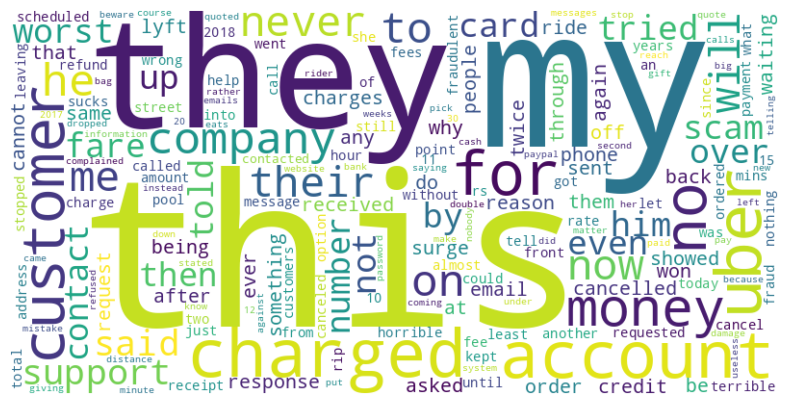

In [61]:
#visualize the the dictionary word by worldcloud techniques and how it is messy
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_coef_dict)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#Another way of  of NLP anlaysis

In [40]:
#at the begining we converts some values manually but her we can get the same result as we will use  automatic
# sentiment analyisis ready tools
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# Download the lexicon
nltk.download('vader_lexicon')

# Load  the  dataset
dff = pd.read_excel('/content/sample_data/Uber Review Data.xlsx') # Ensure you have a 'text_column'
analyzer = SentimentIntensityAnalyzer()

# Apply sentiment scoring
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(str(text))
    # 'compound' is the aggregate score from -1 (negative) to 1 (positive)
    if score['compound'] >= 0.05:
        return 'Positive'
    elif score['compound'] <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

dff['sentiment'] = dff['Comment'].apply(get_vader_sentiment)
print(dff[['Comment', 'sentiment']].head(10))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


                                             Comment sentiment
0  I had an accident with an Uber driver in Mexic...  Negative
1  I have had my account completely hacked to whe...  Negative
2  I requested an 8 mile ride in Boston on a Satu...   Neutral
3  I've been driving off and on with the company ...  Positive
4  Uber is overcharging for Toll fees. When In Fl...  Negative
5  I had an airport flight today. Uber would not ...  Negative
6  I worked for Uber and Lyft for 2.5 years and a...  Negative
7  In July of this year I had sushi delivered to ...  Positive
8  My driver, Rohan was nice, but when I tried to...  Negative
9  I had seven fraudulent Uber transactions over ...  Negative


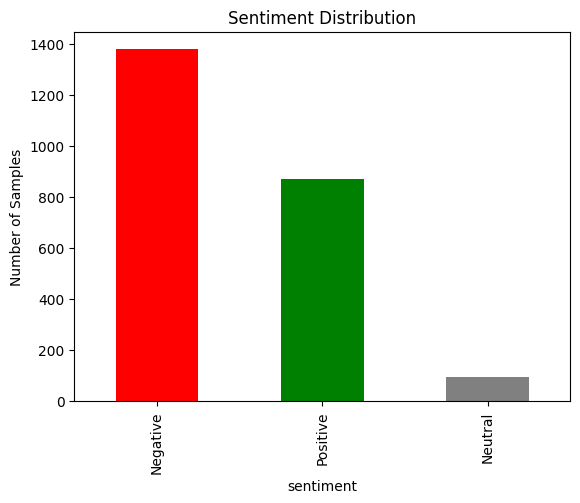

In [42]:
dff['sentiment'].value_counts().plot(kind='bar', color=['red', 'green', 'grey'])
plt.title('Sentiment Distribution')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
#so we can look  and take a vesion about the negativity of and teh poisitivity of customers about

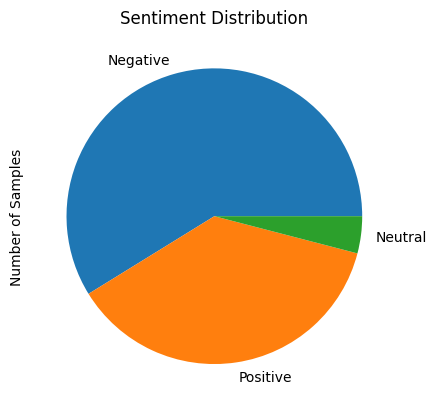

In [43]:
# or malke it pie
dff['sentiment'].value_counts().plot(kind='pie', color=['red', 'green', 'grey'])
plt.title('Sentiment Distribution')
plt.ylabel('Number of Samples')
plt.show()